In [ ]:
import pandas as pd
# Load the cleaned data
df = pd.read_csv("../Data/cleaned_lendingclub.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_default,issue_year,issue_month
0,3600.0,3600.0,3600.0,36,13.99,123.03,C,C4,10.0,MORTGAGE,...,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0,2015,12
1,24700.0,24700.0,24700.0,36,11.99,820.28,C,C1,10.0,MORTGAGE,...,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0,2015,12
2,20000.0,20000.0,20000.0,60,10.78,432.66,B,B4,10.0,MORTGAGE,...,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0,2015,12
3,10400.0,10400.0,10400.0,60,22.45,289.91,F,F1,3.0,MORTGAGE,...,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0,2015,12
4,11950.0,11950.0,11950.0,36,13.44,405.18,C,C3,4.0,RENT,...,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0,2015,12


#1. Check Class Balance (Default vs Non-Default)

<Axes: title={'center': 'Class Distribution'}, xlabel='loan_default'>

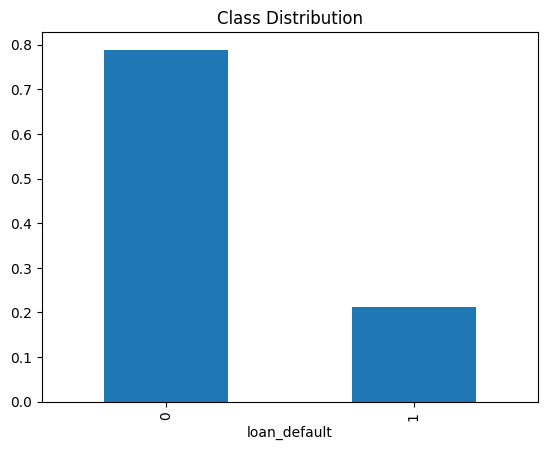

In [ ]:
df['loan_default'].value_counts(normalize=True).plot(kind='bar', title='Class Distribution')

#2. Default Rate by Loan Grade

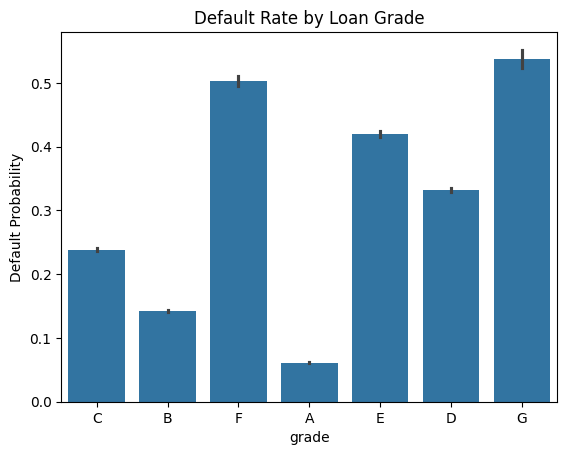

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='grade', y='loan_default', data=df)
plt.title("Default Rate by Loan Grade")
plt.ylabel("Default Probability")
plt.show()

#3. Default Rate by Loan Purpose

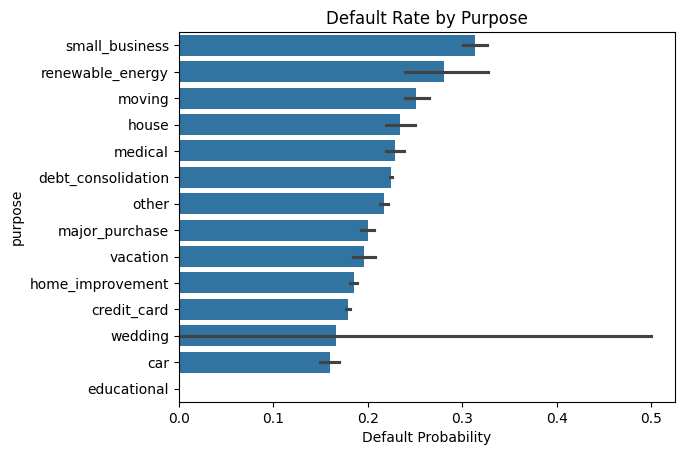

In [ ]:
purpose_order = df.groupby('purpose')['loan_default'].mean().sort_values(ascending=False).index
sns.barplot(x='loan_default', y='purpose', data=df, order=purpose_order)
plt.title("Default Rate by Purpose")
plt.xlabel("Default Probability")
plt.show()

#4. Numerical Distributions: DTI, FICO, Annual Income

Text(0.5, 1.0, 'Log(Annual Income) by Default Status')

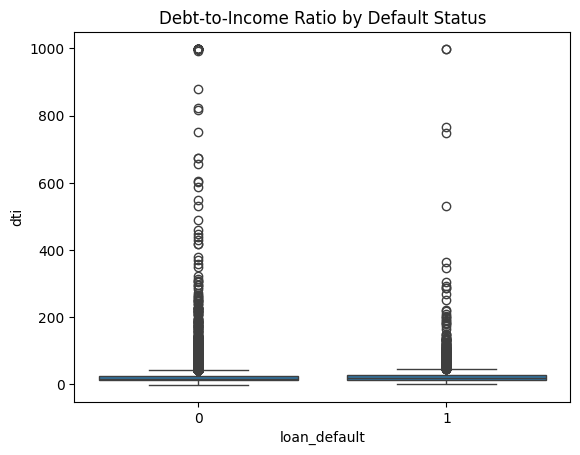

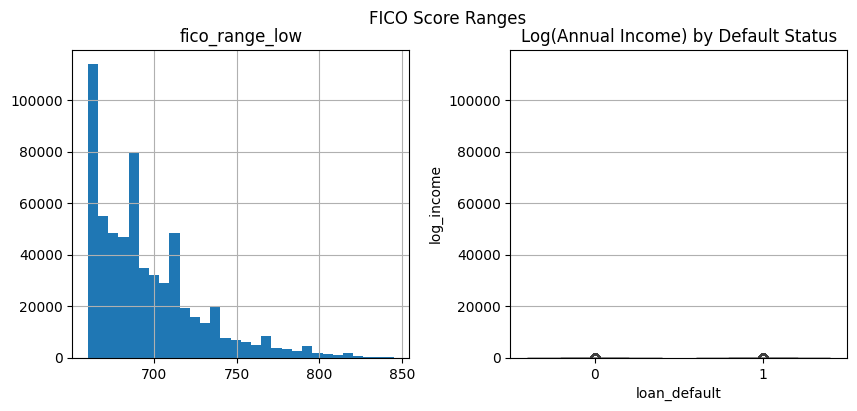

In [ ]:
# DTI vs Default
sns.boxplot(x='loan_default', y='dti', data=df)
plt.title("Debt-to-Income Ratio by Default Status")

# FICO Score Distribution
df[['fico_range_low', 'fico_range_high']].hist(bins=30, figsize=(10,4))
plt.suptitle("FICO Score Ranges")

# Annual Income (Log-scaled to handle skew)
import numpy as np
df['log_income'] = np.log1p(df['annual_inc'])
sns.boxplot(x='loan_default', y='log_income', data=df)
plt.title("Log(Annual Income) by Default Status")

Text(0.5, 1.0, 'Log(Annual Income) by Default Status')

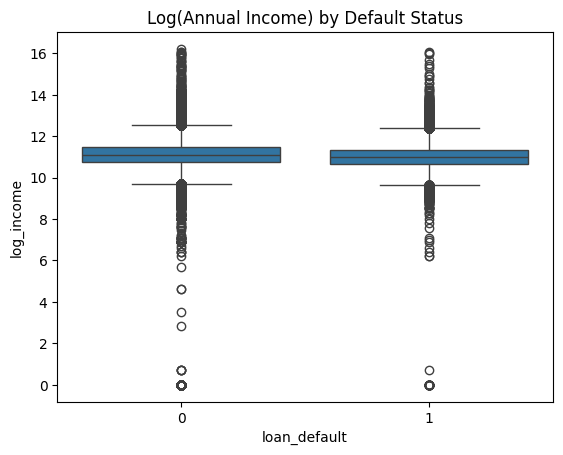

In [ ]:
import numpy as np
df['log_income'] = np.log1p(df['annual_inc'])

sns.boxplot(x='loan_default', y='log_income', data=df)
plt.title("Log(Annual Income) by Default Status")

In [ ]:
# 1. Check emp_length format
print("Unique emp_length values:")
print(df['emp_length'].value_counts(dropna=False))

# 2. Check term format
print("\nUnique term values:")
print(df['term'].value_counts(dropna=False))

# 3. Confirm all relevant date columns are datetime
date_cols = ['issue_d', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d']
for col in date_cols:
    if col in df.columns:
        print(f"\n{col} dtype: {df[col].dtype}")

# 4. Check sub_grade granularity (if exists)
if 'sub_grade' in df.columns:
    print("\nSample sub_grade values:")
    print(df['sub_grade'].value_counts().sort_index())

# 5. Check top categorical features for encoding
for col in ['home_ownership', 'purpose', 'verification_status']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].value_counts(dropna=False))

# 6. Check top null columns
print("\nTop 10 columns with missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Unique emp_length values:
emp_length
10.0    202275
6.0      63500
2.0      55684
0.0      50724
3.0      49253
1.0      40965
5.0      36710
4.0      36427
8.0      28147
7.0      24701
9.0      23394
Name: count, dtype: int64

Unique term values:
term
36    466550
60    145230
Name: count, dtype: int64

Sample sub_grade values:
sub_grade
A1    24507
A2    18686
A3    17646
A4    24558
A5    31628
B1    32345
B2    32720
B3    35267
B4    35997
B5    36884
C1    38900
C2    36437
C3    34560
C4    34408
C5    30497
D1    22194
D2    18490
D3    16828
D4    15139
D5    13390
E1    10621
E2     9945
E3     8531
E4     7072
E5     6746
F1     4177
F2     3067
F3     2486
F4     2002
F5     1705
G1     1307
G2      965
G3      785
G4      674
G5      616
Name: count, dtype: int64

Unique values in home_ownership:
home_ownership
MORTGAGE    298506
RENT        243394
OWN          69863
ANY             15
NONE             2
Name: count, dtype: int64

Unique values in purpose:
purpose
debt_co

In [ ]:
### ---------- 5. Combine rare values in home_ownership ----------
df['home_ownership'] = df['home_ownership'].replace(['NONE', 'ANY', 'OTHER'], 'OTHER')

### ---------- 6. Combine rare purposes (<5000 loans) ----------
purpose_counts = df['purpose'].value_counts()
rare_purposes = purpose_counts[purpose_counts < 5000].index
df['purpose'] = df['purpose'].replace(rare_purposes, 'other')

### ---------- 7. Create average FICO score ----------
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

### ---------- 9. Drop unused or duplicate columns ----------
drop_cols = [
    'fico_range_low', 'fico_range_high'
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [ ]:
df[['issue_year', 'issue_month']].head()

,issue_year,issue_month
0,2015,12
1,2015,12
2,2015,12
3,2015,12
4,2015,12


In [ ]:
df.to_csv("pre_encoded_lendingclub.csv", index=False)